# 4次Childs–Schubert–Mendl比較

このノートブックでは、**同じ統合済み4次Suzuki公式**に対する2種類の誤差上界を比較します。検証済みのAPIで各上界を計算し、その上界から選ばれた反復回数に対するトランスパイル後のClifford+T資源も数えます。

- **Childs Appendix M:** 2グループでは式(M13)、3グループではTable IIを使う、4次公式専用の小prefactor構成。
- **Schubert–Mendl centered bound:** 同じSuzuki因子列を通常の中心で評価したTheorem 1。
- **Childs general proof relaxation:** 保守的な補助診断であり、主比較には用いません。

Hamiltonianのグループ分け、因子の順序、統合済み指数演算子、ノルムの規約、公式の次数、時間発展時間、目標誤差は、比較全体で明示的に固定します。

## 1. 設定と比較規約

1回の4次ステップについて、両上界は次の形を持ちます。

$$\lVert S_4(\delta)-e^{-iH\delta}\rVert \le C_5|\delta|^5.$$

時間を`r`個の等しい区間に分けると、ユニタリのテレスコーピングにより全体の上界は

$$\epsilon_{\mathrm{bound}}(r)=C_5|t|^5/r^4.$$

主比較はChilds Appendix MとSchubert–Mendl centeredです。一般Childs緩和は保守的な診断用としてのみ残します。Appendix Mの中心は2グループ公式でs=6、3グループ公式でs=10に固定し、Schubert–Mendlは通常の中心s=6およびs=11を使います。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["font.family"] = "Yu Gothic"

from hamiltonian_resources import (
    build_fourth_order_bound_problem,
    build_trotter_circuit,
    childs_fourth_order_small_prefactor_bound,
    childs_general_commutator_bound,
    count_circuit_resources,
    heisenberg_chain,
    schubert_mendl_small_prefactor_bound,
    transverse_field_ising,
)

ORDER = 4
TIME = 0.2
NORM_METHOD = "pauli-l1"
ROTATION_SYNTHESIS_ERROR = 1e-4
OPTIMIZATION_LEVEL = 1
SYSTEM_SIZE_POINTS = tuple(np.unique(np.round(np.geomspace(3, 200, 24)).astype(int)))
HEISENBERG_SYSTEM_SIZE_POINTS = tuple(np.unique(np.round(np.geomspace(3, 50, 16)).astype(int)))
TARGET_ERRORS = tuple(np.logspace(-2, -8, 13))
RESOURCE_TARGET_ERRORS = (1e-2, 3e-3, 1e-3)
BASE_QUBITS = 3
DISPLAY_NAMES = {
    "Childs Appendix M": "Childs Appendix M（付録M）",
    "Schubert--Mendl centered": "Schubert–Mendl（中心）",
    "Childs general": "Childs一般評価（診断）",
}

pd.set_option("display.max_columns", None)

## 2. 共通の4次問題設定

比較用の問題オブジェクトはHamiltonianごとに1度だけ構築します。すべての評価器に同じオブジェクトを渡すため、以下の差は積公式の変更ではなく、誤差上界の構成方法の差に由来します。

In [2]:
def model_cases(num_qubits):
    return {
        "TFIM": transverse_field_ising(num_qubits, coupling=1.0, field=0.7),
        "Heisenberg": heisenberg_chain(num_qubits, coupling=1.0, field_z=0.3),
    }

def compare_bound_methods(hamiltonian):
    problem = build_fourth_order_bound_problem(
        hamiltonian, partition="auto", merge_adjacent=True
    )
    results = {
        "Childs general": childs_general_commutator_bound(
            problem, norm_method=NORM_METHOD
        ),
        "Schubert--Mendl centered": schubert_mendl_small_prefactor_bound(
            problem, center=problem.centered_index, norm_method=NORM_METHOD
        ),
        "Childs Appendix M": childs_fourth_order_small_prefactor_bound(
            problem, norm_method=NORM_METHOD
        ),
    }
    return problem, results

base_problems = {}
base_results = {}
for name, hamiltonian in model_cases(BASE_QUBITS).items():
    base_problems[name], base_results[name] = compare_bound_methods(hamiltonian)
    problem = base_problems[name]
    print(
        f"{name}: グループ数={problem.group_count}, グループサイズ={problem.group_sizes}, "
        f"統合後の指数演算子数={problem.exponential_count}, 中心s={problem.centered_index}"
    )

TFIM: グループ数=2, グループサイズ=(2, 3), 統合後の指数演算子数=11, 中心s=6


Heisenberg: グループ数=3, グループサイズ=(4, 4, 1), 統合後の指数演算子数=21, 中心s=11


In [3]:
def result_table(problem, results, target_error=1e-3):
    rows = []
    for method, result in results.items():
        required = (
            result.required_segments(TIME, target_error)
            if result.status == "ok"
            else None
        )
        rows.append({
            "method": DISPLAY_NAMES[method],
            "bound_family": result.bound_family,
            "C5": result.one_step_coefficient,
            "center_s": result.center_index,
            "required_segments": required,
            "status": result.status,
            "rigorous": result.rigorous,
        })
    return pd.DataFrame(rows)

for name in base_problems:
    print(f"{name}の結果")
    display(result_table(base_problems[name], base_results[name]))

TFIMの結果


,method,bound_family,C5,center_s,required_segments,status,rigorous
0,Childs一般評価（診断）,childs-general-commutator,2.545237e+06,NaN,31,ok,True
1,Schubert–Mendl（中心）,schubert-mendl-small-prefactor,8.438238e+00,6.0,2,ok,True
2,Childs Appendix M（付録M）,childs-fourth-order-small-prefactor,8.438238e+00,6.0,2,ok,True


Heisenbergの結果


,method,bound_family,C5,center_s,required_segments,status,rigorous
0,Childs一般評価（診断）,childs-general-commutator,3.159501e+07,NaN,57,ok,True
1,Schubert–Mendl（中心）,schubert-mendl-small-prefactor,1.330210e+02,11.0,3,ok,True
2,Childs Appendix M（付録M）,childs-fourth-order-small-prefactor,1.415933e+02,10.0,3,ok,True


一般Childsの曲線には意図的に**証明上の緩和**というラベルを付けています。その大きな係数は漸近定理が主張する厳密な数値定数ではなく、この実装で採用した明示的な緩和を反映したものです。

## 3. 反復回数を固定した誤差比較

`r`を固定すると積公式は同一です。変化するのは、計算された誤差上界だけです。

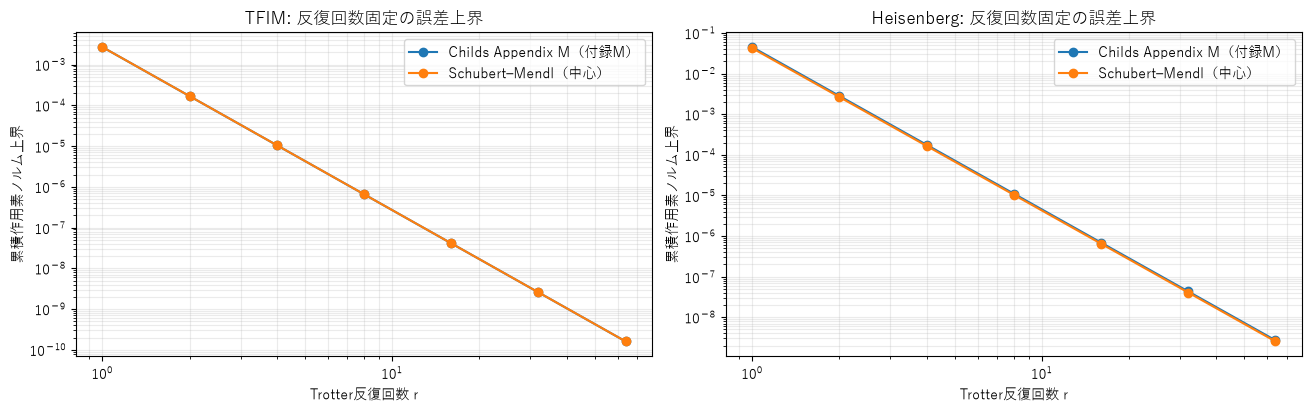

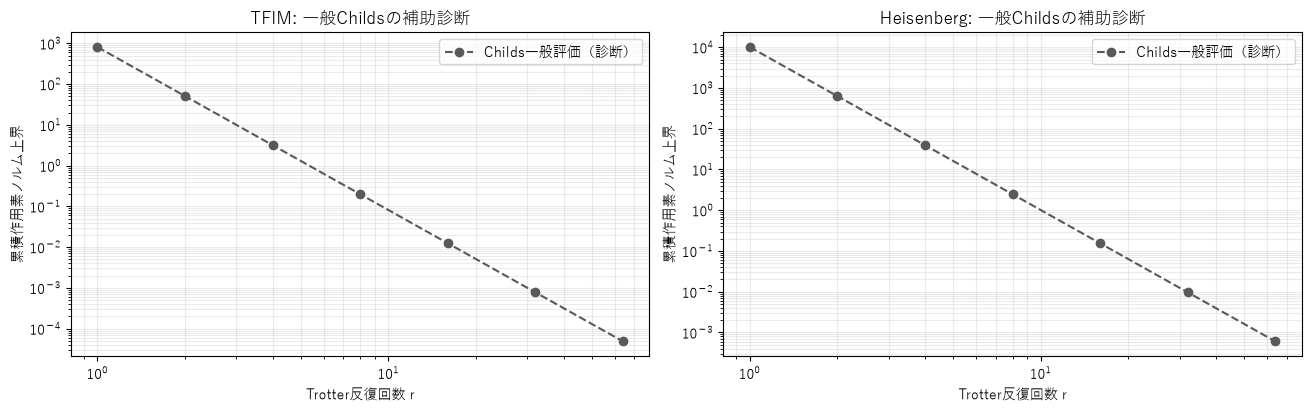

In [4]:
repetition_grid = np.array([1, 2, 4, 8, 16, 32, 64])
primary_methods = ("Childs Appendix M", "Schubert--Mendl centered")
diagnostic_methods = ("Childs general",)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, (name, results) in zip(axes, base_results.items()):
    for method in primary_methods:
        result = results[method]
        errors = [result.accumulated_error_bound(TIME, int(r)) for r in repetition_grid]
        ax.loglog(repetition_grid, errors, marker="o", label=DISPLAY_NAMES[method])
    ax.set_title(f"{name}: 反復回数固定の誤差上界")
    ax.set_xlabel("Trotter反復回数 r")
    ax.set_ylabel("累積作用素ノルム上界")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, (name, results) in zip(axes, base_results.items()):
    result = results[diagnostic_methods[0]]
    errors = [result.accumulated_error_bound(TIME, int(r)) for r in repetition_grid]
    ax.loglog(
        repetition_grid,
        errors,
        marker="o",
        linestyle="--",
        color="0.35",
        label=DISPLAY_NAMES[diagnostic_methods[0]],
    )
    ax.set_title(f"{name}: 一般Childsの補助診断")
    ax.set_xlabel("Trotter反復回数 r")
    ax.set_ylabel("累積作用素ノルム上界")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()

## 4. 系サイズと目標誤差に対する上界のスイープ

TFIMの系サイズスイープでは、N=3からN=200までを対数間隔で選んだ24個の整数点を使います。Heisenbergは3グループの厳密な疎ネスト交換子評価が大きなNで非常に高コストになるためN=50で止めます。ただし、目標誤差の比較では両モデルを使います。

In [5]:
def bound_sweep(model_name, sizes, target_errors):
    rows = []
    for num_qubits in sizes:
        hamiltonian = model_cases(num_qubits)[model_name]
        problem, results = compare_bound_methods(hamiltonian)
        for target_error in target_errors:
            for method in primary_methods:
                result = results[method]
                repetitions = result.required_segments(TIME, target_error)
                rows.append({
                    "model": model_name,
                    "system_qubits": num_qubits,
                    "target_error": target_error,
                    "method": method,
                    "C5": result.one_step_coefficient,
                    "required_segments": repetitions,
                    "continuous_segments": (
                        result.one_step_coefficient * abs(TIME) ** 5 / target_error
                    ) ** 0.25,
                    "accumulated_bound": result.accumulated_error_bound(
                        TIME, repetitions
                    ),
                })
    return pd.DataFrame(rows)

size_frame = pd.concat(
    [bound_sweep("TFIM", SYSTEM_SIZE_POINTS, (1e-3,)),
     bound_sweep("Heisenberg", HEISENBERG_SYSTEM_SIZE_POINTS, (1e-3,))],
    ignore_index=True,
)
error_frame = pd.concat(
    [bound_sweep(name, (BASE_QUBITS,), TARGET_ERRORS) for name in ("TFIM", "Heisenberg")],
    ignore_index=True,
)
size_display = size_frame.copy()
size_display["method"] = size_display["method"].map(DISPLAY_NAMES)
error_display = error_frame.copy()
error_display["method"] = error_display["method"].map(DISPLAY_NAMES)
display(size_display)
display(error_display)

,model,system_qubits,target_error,method,C5,required_segments,continuous_segments,accumulated_bound
0,TFIM,3,0.001,Childs Appendix M（付録M）,8.438238,2,1.281889,0.000169
1,TFIM,3,0.001,Schubert–Mendl（中心）,8.438238,2,1.281889,0.000169
2,TFIM,4,0.001,Childs Appendix M（付録M）,14.723994,2,1.473309,0.000294
3,TFIM,4,0.001,Schubert–Mendl（中心）,14.723994,2,1.473309,0.000294
4,TFIM,5,0.001,Childs Appendix M（付録M）,21.009749,2,1.610248,0.000420
...,...,...,...,...,...,...,...,...
71,Heisenberg,34,0.001,Schubert–Mendl（中心）,17509.722939,9,8.651817,0.000854
72,Heisenberg,41,0.001,Childs Appendix M（付録M）,27073.043914,10,9.647655,0.000866
73,Heisenberg,41,0.001,Schubert–Mendl（中心）,27020.725382,10,9.642991,0.000865
74,Heisenberg,50,0.001,Childs Appendix M（付録M）,51293.715512,12,11.318882,0.000792


,model,system_qubits,target_error,method,C5,required_segments,continuous_segments,accumulated_bound
0,TFIM,3,1.000000e-02,Childs Appendix M（付録M）,8.438238,1,0.720859,2.700236e-03
1,TFIM,3,1.000000e-02,Schubert–Mendl（中心）,8.438238,1,0.720859,2.700236e-03
2,TFIM,3,3.162278e-03,Childs Appendix M（付録M）,8.438238,1,0.961281,2.700236e-03
3,TFIM,3,3.162278e-03,Schubert–Mendl（中心）,8.438238,1,0.961281,2.700236e-03
4,TFIM,3,1.000000e-03,Childs Appendix M（付録M）,8.438238,2,1.281889,1.687648e-04
5,TFIM,3,1.000000e-03,Schubert–Mendl（中心）,8.438238,2,1.281889,1.687648e-04
6,TFIM,3,3.162278e-04,Childs Appendix M（付録M）,8.438238,2,1.709427,1.687648e-04
7,TFIM,3,3.162278e-04,Schubert–Mendl（中心）,8.438238,2,1.709427,1.687648e-04
8,TFIM,3,1.000000e-04,Childs Appendix M（付録M）,8.438238,3,2.279557,3.333625e-05
9,TFIM,3,1.000000e-04,Schubert–Mendl（中心）,8.438238,3,2.279557,3.333625e-05


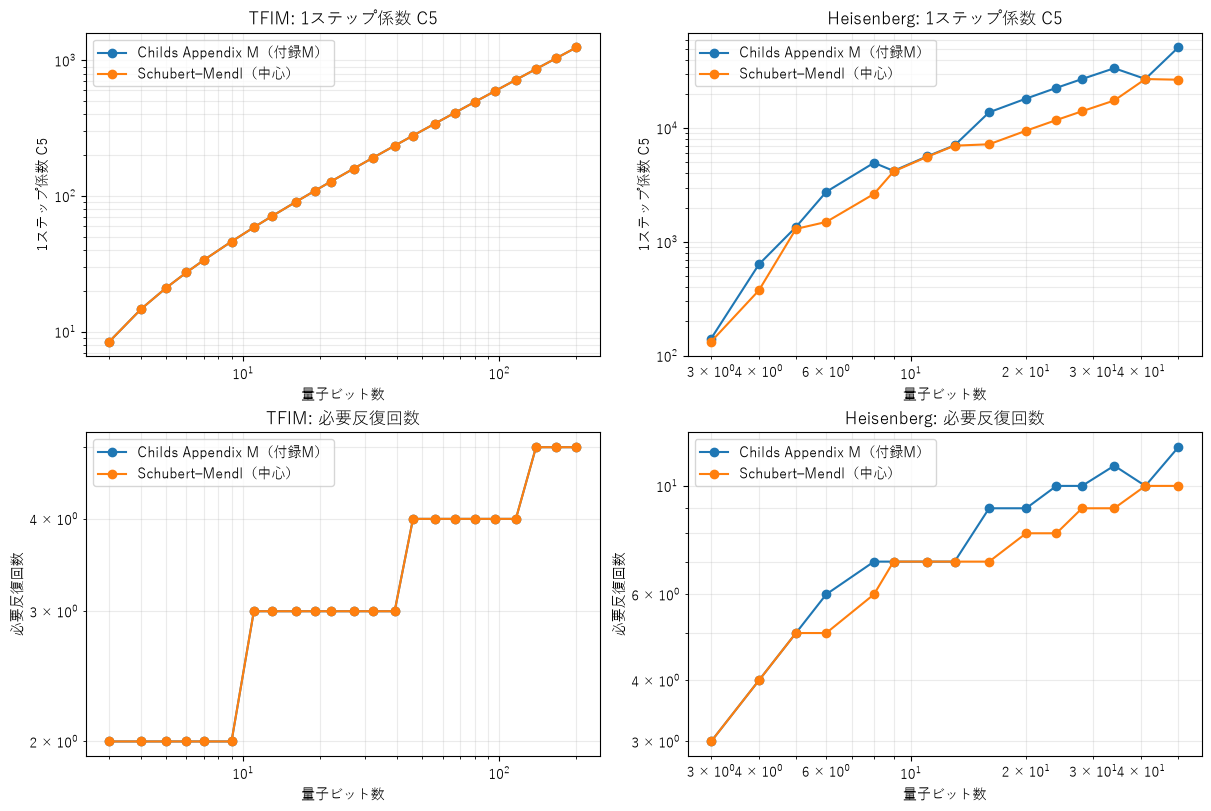

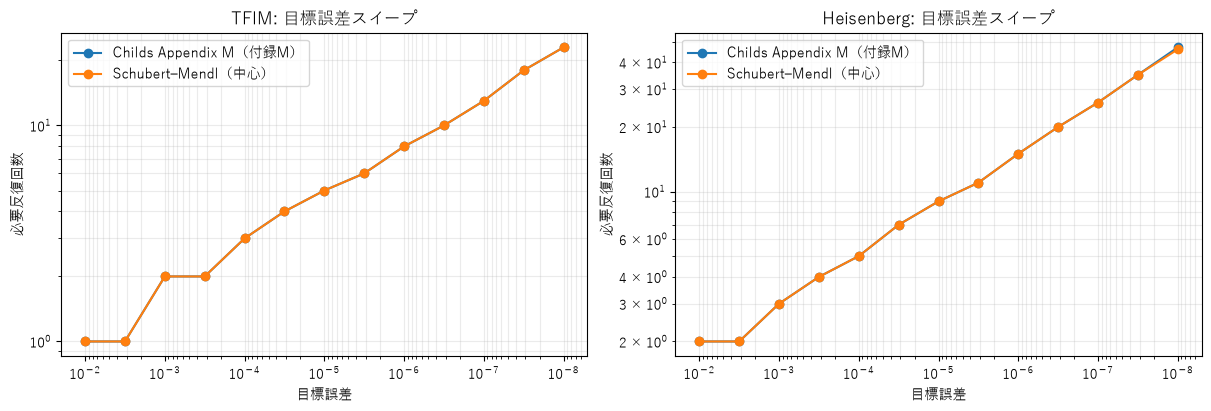

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for column, ylabel, row in (("C5", "1ステップ係数 C5", 0), ("required_segments", "必要反復回数", 1)):
    for col, model_name in enumerate(("TFIM", "Heisenberg")):
        ax = axes[row, col]
        subset = size_frame[size_frame.model == model_name]
        for method in primary_methods:
            curve = subset[subset.method == method]
            ax.loglog(curve.system_qubits, curve[column], marker="o", label=DISPLAY_NAMES[method])
        ax.set_title(f"{model_name}: {ylabel}")
        ax.set_xlabel("量子ビット数")
        ax.set_ylabel(ylabel)
        ax.grid(True, which="both", alpha=0.25)
        ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, model_name in zip(axes, ("TFIM", "Heisenberg")):
    subset = error_frame[error_frame.model == model_name]
    for method in primary_methods:
        curve = subset[subset.method == method].sort_values("target_error")
        ax.loglog(curve.target_error, curve.required_segments, marker="o", label=DISPLAY_NAMES[method])
    ax.set_title(f"{model_name}: 目標誤差スイープ")
    ax.set_xlabel("目標誤差")
    ax.set_ylabel("必要反復回数")
    ax.invert_xaxis()
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()

,model,method,slope_C5_vs_N,slope_continuous_segments_vs_N,slope_continuous_segments_vs_epsilon
0,TFIM,Childs Appendix M（付録M）,1.131401,0.282850,-0.25
1,TFIM,Schubert–Mendl（中心）,1.131401,0.282850,-0.25
2,Heisenberg,Childs Appendix M（付録M）,1.802553,0.450638,-0.25
3,Heisenberg,Schubert–Mendl（中心）,1.684553,0.421138,-0.25


4次上界で期待される目標誤差の傾き: -1/4 = -0.25


method,system_qubits,Childs Appendix M,Schubert--Mendl centered,C5_ratio_Appendix_M_over_Schubert,model,sweep,target_error
0,3.0,8.438238,8.438238,1.000000,TFIM,system_qubits,NaN
1,4.0,14.723994,14.723994,1.000000,TFIM,system_qubits,NaN
2,5.0,21.009749,21.009749,1.000000,TFIM,system_qubits,NaN
3,6.0,27.295505,27.295505,1.000000,TFIM,system_qubits,NaN
4,7.0,33.581260,33.581260,1.000000,TFIM,system_qubits,NaN
...,...,...,...,...,...,...,...
59,NaN,141.593278,133.021010,1.064443,Heisenberg,target_error,0.000100
60,NaN,141.593278,133.021010,1.064443,Heisenberg,target_error,0.000316
61,NaN,141.593278,133.021010,1.064443,Heisenberg,target_error,0.001000
62,NaN,141.593278,133.021010,1.064443,Heisenberg,target_error,0.003162


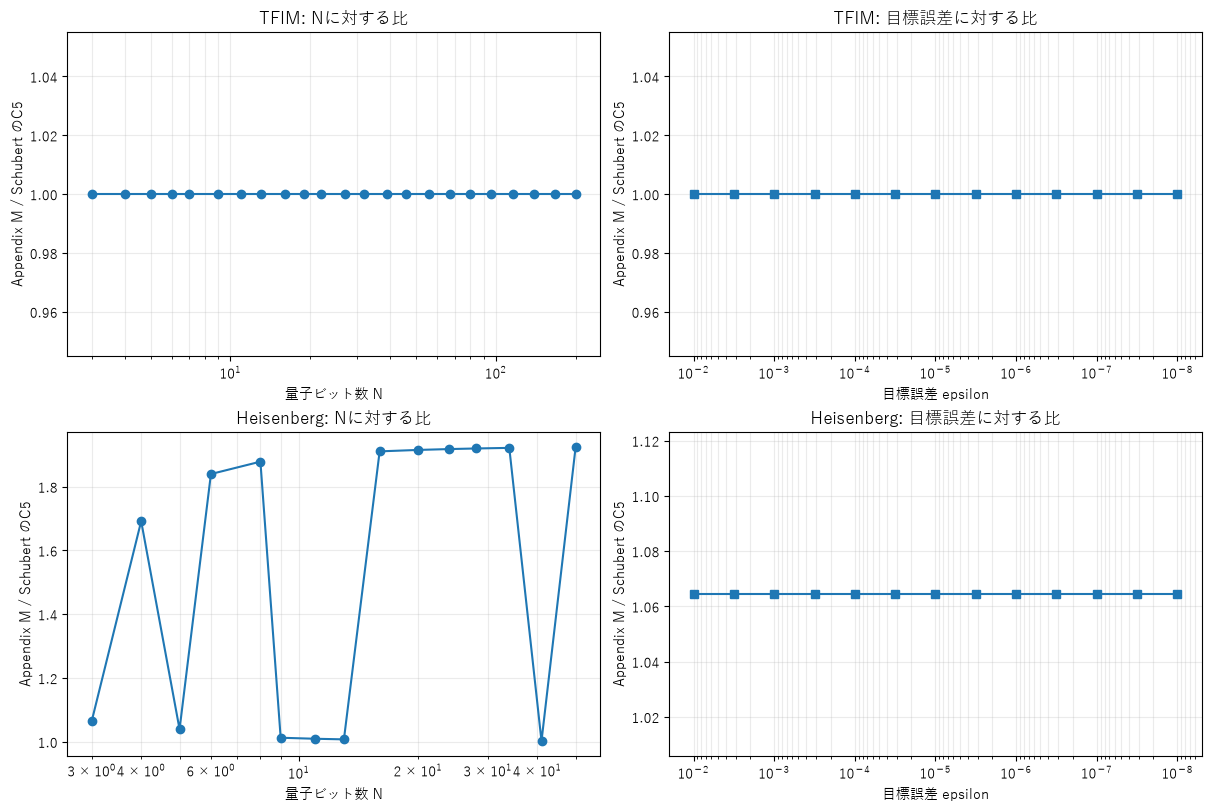

In [7]:
def loglog_slope(frame, x_column, y_column, method):
    curve = frame[frame.method == method].sort_values(x_column)
    return float(np.polyfit(np.log(curve[x_column]), np.log(curve[y_column]), 1)[0])

slope_rows = []
for model_name in ("TFIM", "Heisenberg"):
    for method in primary_methods:
        size_curve = size_frame[size_frame.model == model_name]
        error_curve = error_frame[error_frame.model == model_name]
        slope_rows.append({
            "model": model_name,
            "method": method,
            "slope_C5_vs_N": loglog_slope(size_curve, "system_qubits", "C5", method),
            "slope_continuous_segments_vs_N": loglog_slope(size_curve, "system_qubits", "continuous_segments", method),
            "slope_continuous_segments_vs_epsilon": loglog_slope(error_curve, "target_error", "continuous_segments", method),
        })
slope_frame = pd.DataFrame(slope_rows)
display(slope_frame.assign(method=slope_frame.method.map(DISPLAY_NAMES)))
print("4次上界で期待される目標誤差の傾き: -1/4 = -0.25")

ratio_rows = []
for model_name in ("TFIM", "Heisenberg"):
    for source_frame, x_column in ((size_frame, "system_qubits"), (error_frame, "target_error")):
        subset = source_frame[source_frame.model == model_name]
        pivot = subset.pivot(index=x_column, columns="method", values="C5").reset_index()
        pivot["C5_ratio_Appendix_M_over_Schubert"] = pivot["Childs Appendix M"] / pivot["Schubert--Mendl centered"]
        pivot["model"] = model_name
        pivot["sweep"] = x_column
        ratio_rows.append(pivot)
ratio_frame = pd.concat(ratio_rows, ignore_index=True)
display(ratio_frame)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for row, model_name in enumerate(("TFIM", "Heisenberg")):
    size_ratio = ratio_frame[(ratio_frame.model == model_name) & (ratio_frame.sweep == "system_qubits")].sort_values("system_qubits")
    error_ratio = ratio_frame[(ratio_frame.model == model_name) & (ratio_frame.sweep == "target_error")].sort_values("target_error")
    axes[row, 0].semilogx(size_ratio.system_qubits, size_ratio.C5_ratio_Appendix_M_over_Schubert, marker="o")
    axes[row, 0].set_title(f"{model_name}: Nに対する比")
    axes[row, 0].set_xlabel("量子ビット数 N")
    axes[row, 0].set_ylabel("Appendix M / Schubert のC5")
    axes[row, 0].grid(True, which="both", alpha=0.25)
    axes[row, 1].semilogx(error_ratio.target_error, error_ratio.C5_ratio_Appendix_M_over_Schubert, marker="s")
    axes[row, 1].set_title(f"{model_name}: 目標誤差に対する比")
    axes[row, 1].set_xlabel("目標誤差 epsilon")
    axes[row, 1].set_ylabel("Appendix M / Schubert のC5")
    axes[row, 1].invert_xaxis()
    axes[row, 1].grid(True, which="both", alpha=0.25)
plt.show()

## スケーリング結果の解釈

2つの主比較手法では、4次公式による累積誤差上界は同じ関数形を持ちます。

$$r_{\min}=\left\lceil\left(C_5|t|^5/\epsilon\right)^{1/4}\right\rceil.$$

整数反復数のグラフに現れる階段状の形は、天井関数によるものです。Trotter反復数は整数でなければなりません。これはSchubert–Mendlの漸近次数が異なることを示すものではありません。連続値の反復数を使った曲線では、この丸めの影響を除いています。

したがって、系サイズを固定すると、両手法の目標誤差に対する指数は同じです。

$$r\propto\epsilon^{-1/4}.$$

主比較における連続値の反復数の比は次のようになります。

$$\frac{r_{\mathrm{Appendix\ M}}}{r_{\mathrm{SM}}} \approx \left(\frac{C_5^{\mathrm{Appendix\ M}}}{C_5^{\mathrm{SM}}}\right)^{1/4}.$$

整数反復数の比は丸めのため、この値の周辺で変動します。TFIMの`N=3`では、Appendix MとSchubert–Mendlの`s=6`が同じ`C5 = 8.44`を与えるため、主曲線も一致します。HeisenbergではAppendix Mが`s=10`、centered版Schubert–Mendlが`s=11`を使うため、`C5`はそれぞれ約`141.59`と`133.02`になります。

2つの主比較手法が定数倍の違いだけで等価かどうかは、Nを大きくしたときにAppendix MとSchubert–Mendlの`C5`比が一定値へ近づくかで判断できます。TFIMでは`s=6`で2グループ用の構成が一致するため、比は1です。Heisenbergで1からずれる主な理由は、一般Childs緩和ではなく、中心・因子分解の違い（`s=10`対`s=11`）です。

両方のprefactorが`C5 ~ N^a`でスケールするなら、

$$r\sim N^{a/4}\epsilon^{-1/4}.$$

これらの局所鎖では、4次Suzukiの1反復あたりの回路コストはおよそ`N`に比例します。そのため、誤差を固定したときのT countとCNOT countは概ね`N^{1+a/4}`でスケールすると期待されます。したがってprefactorの定数倍の差は資源曲線の縦方向の位置を変え、フィットされたNの指数の差は漸近的な傾きを変えます。

## 5. Appendix Mの整合性チェック

2グループのTFIM分解では、Childs Appendix Mは11個の指数演算子からなる統合公式の中心`s=6`を使います。同じ中心で評価したSchubert–Mendlは、各項および総和で一致するはずです。3グループのHeisenberg分解では、Appendix MはTable IIの`s=10`の因子分解を使います。Schubert–Mendlの`s=10`はAppendix Mと一致するはずですが、通常のcentered版は`s=11`を使うため、中心の違いによって異なる可能性があります。

In [8]:
tfim_problem = base_problems["TFIM"]
appendix = base_results["TFIM"]["Childs Appendix M"]
schubert_s6 = schubert_mendl_small_prefactor_bound(
    tfim_problem, center=6, norm_method=NORM_METHOD
)

print("統合後の指数演算子数:", tfim_problem.exponential_count)
print("Appendix MのC5:", appendix.one_step_coefficient)
print("Schubert s=6のC5:", schubert_s6.one_step_coefficient)
assert tfim_problem.exponential_count == 11
assert np.isclose(appendix.one_step_coefficient, schubert_s6.one_step_coefficient)

heisenberg_problem = base_problems["Heisenberg"]
heisenberg_appendix = base_results["Heisenberg"]["Childs Appendix M"]
schubert_s10 = schubert_mendl_small_prefactor_bound(
    heisenberg_problem, center=10, norm_method=NORM_METHOD
)
heisenberg_centered = base_results["Heisenberg"]["Schubert--Mendl centered"]
print("Heisenbergの統合後の指数演算子数:", heisenberg_problem.exponential_count)
print("Appendix M s=10のC5:", heisenberg_appendix.one_step_coefficient)
print("Schubert s=10のC5:", schubert_s10.one_step_coefficient)
print("Schubert centered s=11のC5:", heisenberg_centered.one_step_coefficient)
assert heisenberg_problem.exponential_count == 21
assert heisenberg_appendix.center_index == 10
assert heisenberg_centered.center_index == 11
assert np.isclose(heisenberg_appendix.one_step_coefficient, schubert_s10.one_step_coefficient)

統合後の指数演算子数: 11
Appendix MのC5: 8.438238289913093
Schubert s=6のC5: 8.438238289913093
Heisenbergの統合後の指数演算子数: 21
Appendix M s=10のC5: 141.59327838399705
Schubert s=10のC5: 141.59327838399705
Schubert centered s=11のC5: 133.02101049015127


## 6. 手法ごとのトランスパイル後T countとCNOT count

資源スイープでは、各主比較手法が独立に選んだ反復回数を使います。トランスパイル後の`cx`ゲート数を数え、得られた`rz`回転に対するClifford+Tコストを見積もります。資源比較の主役はAppendix MとSchubert–Mendlです。一般Childs緩和は、上界表と反復回数固定の診断グラフにおける保守的な補助診断としてのみ残します。

In [9]:
def resource_sweep(model_name, sizes=(3,), target_errors=RESOURCE_TARGET_ERRORS):
    rows = []
    for num_qubits in sizes:
        hamiltonian = model_cases(num_qubits)[model_name]
        problem, results = compare_bound_methods(hamiltonian)
        for target_error in target_errors:
            algorithm_error = target_error - ROTATION_SYNTHESIS_ERROR
            if algorithm_error <= 0:
                raise ValueError("目標誤差は回転合成誤差より大きくしてください")
            for method in primary_methods:
                bound_result = results[method]
                repetitions = bound_result.required_segments(TIME, algorithm_error)
                circuit = build_trotter_circuit(
                    hamiltonian,
                    TIME,
                    repetitions,
                    ORDER,
                    partition="auto",
                )
                resource = count_circuit_resources(
                    circuit,
                    algorithm=method,
                    total_synthesis_error=ROTATION_SYNTHESIS_ERROR,
                    optimization_level=OPTIMIZATION_LEVEL,
                )
                row = resource.as_dict()
                row.update(
                    model=model_name,
                    method=method,
                    system_qubits=num_qubits,
                    target_error=target_error,
                    repetitions=repetitions,
                    bound_C5=bound_result.one_step_coefficient,
                )
                rows.append(row)
    return pd.DataFrame(rows)

resource_frame = pd.concat(
    [resource_sweep(name) for name in ("TFIM", "Heisenberg")],
    ignore_index=True,
)
resource_display = resource_frame.copy()
resource_display["method"] = resource_display["method"].map(DISPLAY_NAMES)
display(
    resource_display[
        ["model", "target_error", "method", "repetitions", "t_count", "cnot_count", "rotation_count", "depth", "counting_mode"]
    ]
)

,model,target_error,method,repetitions,t_count,cnot_count,rotation_count,depth,counting_mode
0,TFIM,0.010,Childs Appendix M（付録M）,1,2100,40,35,85,transpiled
1,TFIM,0.010,Schubert–Mendl（中心）,1,2100,40,35,85,transpiled
2,TFIM,0.003,Childs Appendix M（付録M）,1,2100,40,35,85,transpiled
3,TFIM,0.003,Schubert–Mendl（中心）,1,2100,40,35,85,transpiled
4,TFIM,0.001,Childs Appendix M（付録M）,2,4410,80,70,170,transpiled
5,TFIM,0.001,Schubert–Mendl（中心）,2,4410,80,70,170,transpiled
6,Heisenberg,0.010,Childs Appendix M（付録M）,2,9966,240,151,600,transpiled
7,Heisenberg,0.010,Schubert–Mendl（中心）,2,9966,240,151,600,transpiled
8,Heisenberg,0.003,Childs Appendix M（付録M）,2,9966,240,151,600,transpiled
9,Heisenberg,0.003,Schubert–Mendl（中心）,2,9966,240,151,600,transpiled


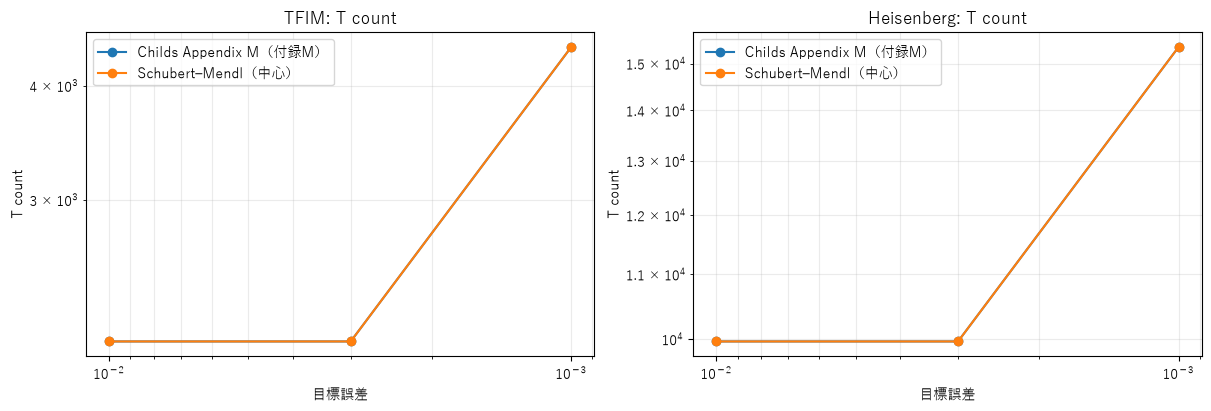

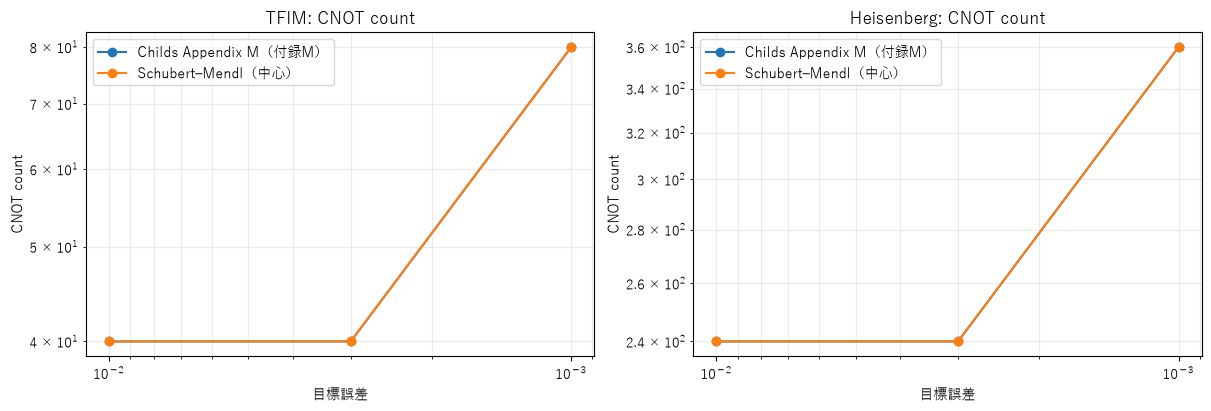

In [10]:
for metric, ylabel in (("t_count", "T count"), ("cnot_count", "CNOT count")):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for ax, model_name in zip(axes, ("TFIM", "Heisenberg")):
        subset = resource_frame[resource_frame.model == model_name]
        for method in primary_methods:
            curve = subset[subset.method == method].sort_values("target_error")
            ax.loglog(curve.target_error, curve[metric], marker="o", label=DISPLAY_NAMES[method])
        ax.set_title(f"{model_name}: {ylabel}")
        ax.set_xlabel("目標誤差")
        ax.set_ylabel(ylabel)
        ax.invert_xaxis()
        ax.grid(True, which="both", alpha=0.25)
        ax.legend()
    plt.show()

## 7. 検証チェック

これらのチェックでは、比較が共通の4次積公式を使っていることと、各手法で選ばれた反復回数がそれぞれのアルゴリズム誤差目標を満たすことを確認します。

In [11]:
for name, problem in base_problems.items():
    assert problem.order == ORDER
    assert problem.merged_consecutive
    assert base_results[name]["Childs general"].status == "ok"
    assert base_results[name]["Childs general"].rigorous
    for method in primary_methods:
        result = base_results[name][method]
        repetitions = result.required_segments(TIME, 9e-4)
        assert result.status == "ok"
        assert result.rigorous
        assert result.accumulated_error_bound(TIME, repetitions) <= 9e-4
        if repetitions > 1:
            assert result.accumulated_error_bound(TIME, repetitions - 1) > 9e-4

assert np.isclose(
    base_results["TFIM"]["Childs Appendix M"].one_step_coefficient,
    schubert_s6.one_step_coefficient,
)
assert np.isclose(
    base_results["Heisenberg"]["Childs Appendix M"].one_step_coefficient,
    schubert_s10.one_step_coefficient,
)
assert not np.isclose(
    base_results["Heisenberg"]["Childs Appendix M"].one_step_coefficient,
    base_results["Heisenberg"]["Schubert--Mendl centered"].one_step_coefficient,
)

assert (resource_frame.t_count > 0).all()
assert (resource_frame.cnot_count > 0).all()
assert set(resource_frame.counting_mode) == {"transpiled"}
print("ノートブックのすべての検証チェックに合格しました。")

ノートブックのすべての検証チェックに合格しました。


## 参考文献

- A. M. Childs, Y. Su, M. C. Tran, N. Wiebe, and S. Zhu, [A Theory of Trotter Error](https://arxiv.org/abs/1912.08854).
- A. Schubert and C. B. Mendl, [Trotter error with commutator scaling for the Fermi-Hubbard model](https://arxiv.org/abs/2306.10603).
- Repository implementation notes: [`docs/fourth_order_bound_comparison.md`](../docs/fourth_order_bound_comparison.md).